In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [70]:
# Removing warnings because who wants to see them
import warnings
warnings.filterwarnings("ignore")

# Display settings for easier DataFrame viewing
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [107]:
df = pd.read_csv('lending_club_dataset.csv')

In [108]:
df.head(8)

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.00,NJ,MORTGAGE,90000.00,Verified,18.01,NaN,NaN,NaN,0,38.00,2001,6,28,10,70795,38767,0,0,38.00,0,1250,2,5,5.00,10,0.00,0,2,11100,14,8,6,1,92.90,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-18,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.00
1,warehouse office clerk,10.00,HI,RENT,40000.00,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.00,14,0.00,0,3,16500,24,14,4,0,100.00,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-18,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.00
2,assembly,3.00,WI,RENT,40000.00,Source Verified,21.15,NaN,NaN,NaN,0,28.00,2006,4,31,10,24193,16000,0,0,28.00,0,432,1,13,7.00,10,0.00,0,3,4300,14,8,6,0,93.50,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-18,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.00
3,customer service,1.00,PA,RENT,30000.00,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.00,4,0.00,0,2,19400,3,3,2,0,100.00,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-18,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.00
4,security supervisor,10.00,CA,RENT,35000.00,Verified,57.96,57000.00,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.00,16,0.00,0,10,32700,20,15,13,0,100.00,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-18,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.00
5,NaN,NaN,KY,OWN,34000.00,Not Verified,6.46,NaN,NaN,NaN,1,3.00,1990,6,32,12,42100,3898,0,0,60.00,0,0,0,2,5.00,12,0.00,0,1,27200,27,12,5,3,78.10,0,0,other,individual,5000,36,6.72,153.75,A,A3,Jan-18,Current,whole,Cash,4256.71,873.13,743.29,129.84,0.00
6,hr,10.00,MI,MORTGAGE,35000.00,Source Verified,23.66,155000.00,Not Verified,13.12,0,NaN,2004,1,12,10,291852,18916,0,0,NaN,0,0,2,1,9.00,10,0.00,0,3,9100,8,7,6,2,100.00,0,0,credit_card,joint,24000,60,13.59,553.35,C,C2,Jan-18,Current,whole,Cash,22560.00,2730.51,1440.00,1290.51,0.00
7,police,10.00,AZ,MORTGAGE,110000.00,Source Verified,16.19,NaN,NaN,NaN,1,19.00,2005,1,30,15,342336,60805,0,0,71.00,0,0,2,4,7.00,15,NaN,0,5,22250,16,12,10,7,93.00,0,0,debt_consolidation,individual,20000,60,11.99,444.79,B,B5,Jan-18,Current,whole,Cash,19005.39,1765.84,994.61,771.23,0.00


In [73]:
df.info()
# we will not delete any null values, rather we will handle them as per requirement

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   str    
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  str    
 3   homeownership                     10000 non-null  str    
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  str    
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   str    
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earliest_credit_

In [109]:
# Parse issue_month to extract the year
# (Assuming issue_month is in 'YYYY-MM-DD' or 'Mon-YYYY' format)
df['issue_month'] = pd.to_datetime(df['issue_month'])
df['issue_year'] = df['issue_month'].dt.year

# 2. Calculate Credit History Length
# earliest_credit_line is just the year (e.g., 2005)
df['credit_history_years'] = df['issue_year'] - df['earliest_credit_line']

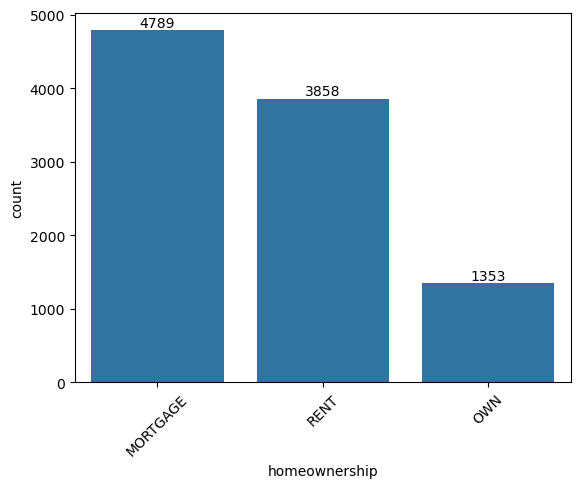

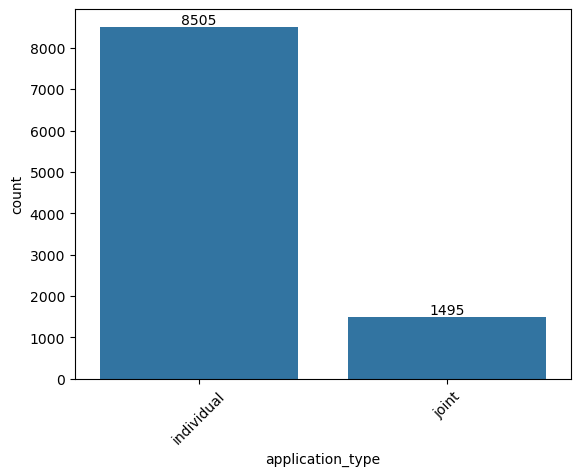

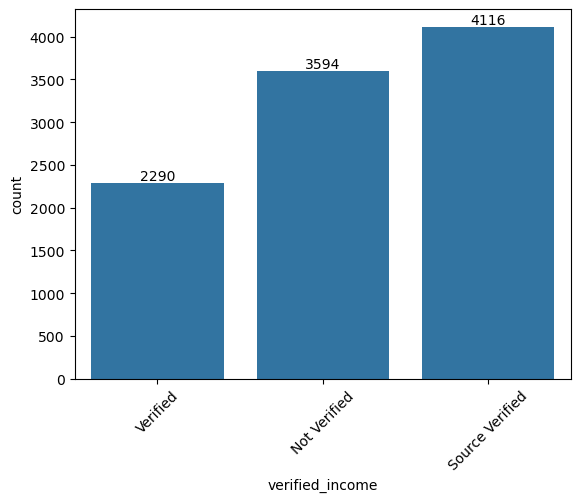

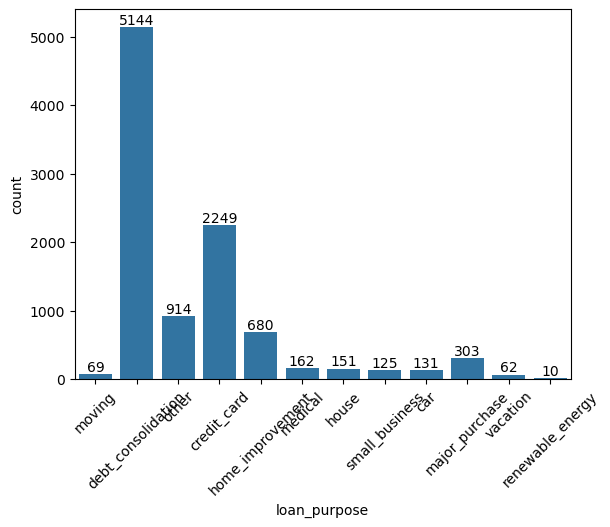

In [110]:
cols = ['homeownership', 'application_type', 'verified_income', 'loan_purpose']

for col in cols:
    ax = sns.countplot(data=df, x=col)
    ax.bar_label(ax.containers[0])
    plt.xticks(rotation=45)
    plt.show()

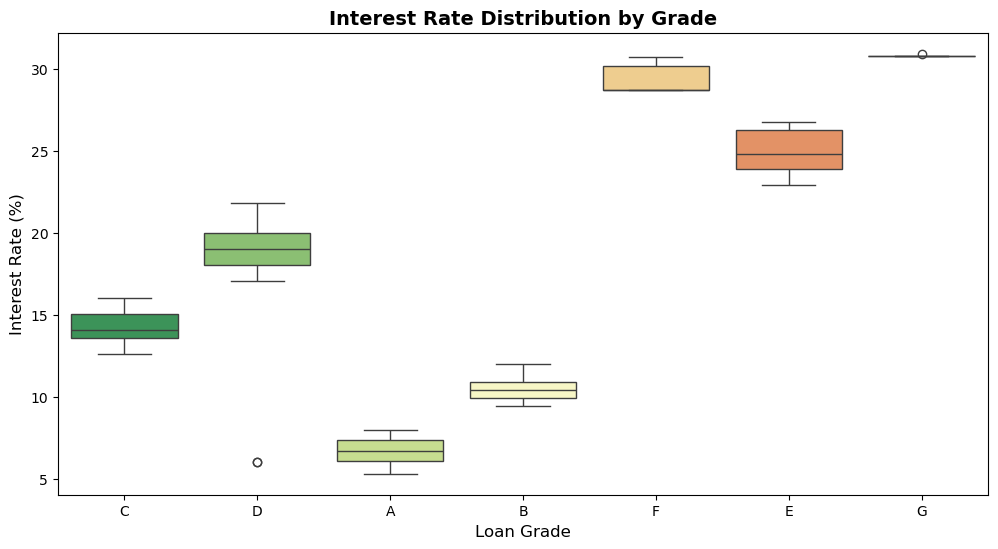

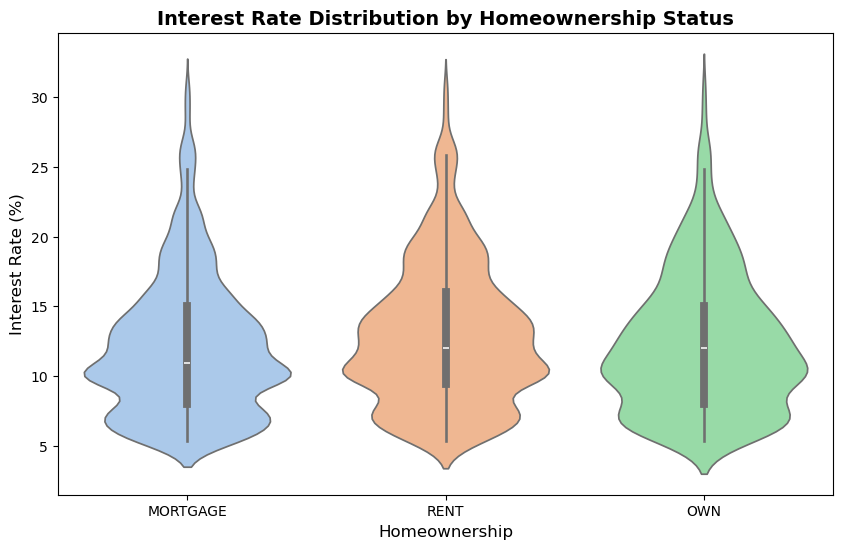

In [111]:
# Box plot: Interest Rate by Grade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='grade', y='interest_rate', palette='RdYlGn_r')
plt.title('Interest Rate Distribution by Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.show()

# Violin plot: Interest Rate by Homeownership
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='homeownership', y='interest_rate', palette='pastel')
plt.title('Interest Rate Distribution by Homeownership Status', fontsize=14, fontweight='bold')
plt.xlabel('Homeownership', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.show()

In [112]:
# Homeownership groups show broadly similar interest-rate distributions,
# with substantial overlap, suggesting only a modest relationship with interest rate.

# Loan grade shows a much clearer pattern: interest rates increase as grade moves from A to G,
# suggesting that loan grade is strongly associated with the interest rate.

In [113]:
# Creating effective income and DTI using joint values where available
df['effective_income'] = df['annual_income_joint'].fillna(df['annual_income'])
df['effective_dti'] = df['debt_to_income_joint'].fillna(df['debt_to_income'])
df.drop(columns=['annual_income', 'annual_income_joint', 'debt_to_income', 'debt_to_income_joint'], inplace=True)

# FEATURE ENGINEERING

In [114]:
# doing feature engineering here itself since a lot of columns will be dropped later

# Affordability Ratio: Monthly loan payment vs Monthly income
# (effective_income is annual, so we divide by 12)
df['installment_to_income'] = df['installment'] / (df['effective_income'] / 12)

# Credit Utilization Ratio
#
df['cr_util_ratio'] = df['total_credit_utilized'] / df['total_credit_limit']
df.loc[df['total_credit_limit'] == 0, 'cr_util_ratio'] = 0

# Loan-to-Income Ratio
# How much of their total household income is this specific loan requesting?
df['loan_to_income'] = df['loan_amount'] / (df['effective_income'])

In [115]:
# Handle nulls in credit history variables by creating flags where null has a meaningful meaning,
# then filling the original values with 0; directly fill past-due account counts with 0


# Flagging whether there was a recent credit inquiry
df['has_recent_inquiry'] = (~df['months_since_last_credit_inquiry'].isna()).astype(int)
# Filling null with 0 after creating the flag
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(0)


#same as above
df['ever_90d_late'] = (~df['months_since_90d_late'].isna()).astype(int)
df['months_since_90d_late'] = df['months_since_90d_late'].fillna(0)

# here Null means no past-due accounts, so fill directly with 0
df['num_accounts_120d_past_due'] = df['num_accounts_120d_past_due'].fillna(0)
df['num_accounts_30d_past_due'] = df['num_accounts_30d_past_due'].fillna(0)

In [116]:
# using same flag and fill trick just like 90d late and recent enquiry
df['has_ever_been_delinquent'] = (~df['months_since_last_delinq'].isna()).astype(int)
df['months_since_last_delinq'] = df['months_since_last_delinq'].fillna(0)

In [117]:
# Creating one income verification status by using the joint status for joint applications, 
# individual status otherwise, then fill remaining nulls and drop the old columns

df['income_verification_status'] = np.where(
    df['application_type'] == 'Joint', 
    df['verification_income_joint'], 
    df['verified_income'] )

df['income_verification_status'] = df['income_verification_status'].fillna('Not Verified')

df.drop(columns=['verified_income', 'verification_income_joint'], inplace=True)

In [118]:
# Handling emp_length nulls using the Flag & Fill trick
# Create a flag: 1 if emp_length was missing, 0 if it was present, then Fill the nulls in the continuous column with 0 
df['emp_length_missing'] = df['emp_length'].isna().astype(int)
df['emp_length'] = df['emp_length'].fillna(0)

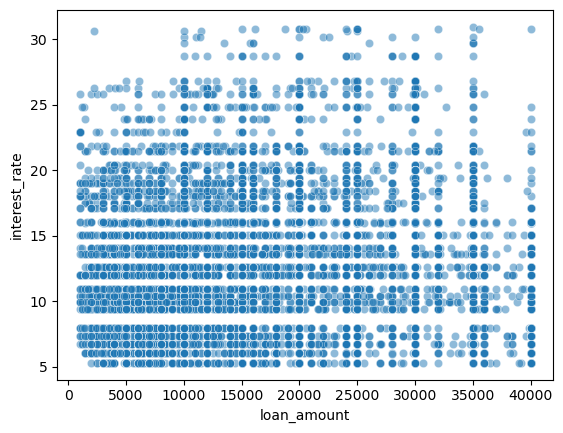

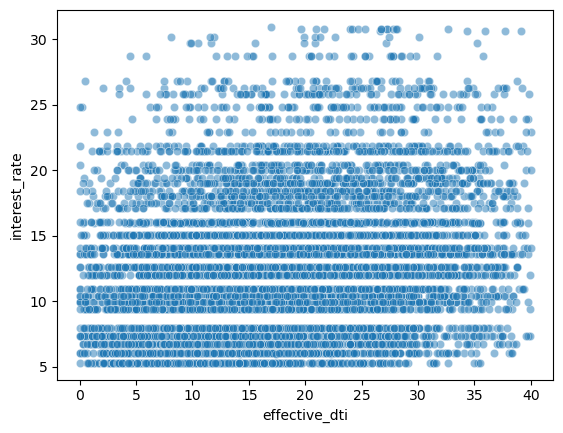

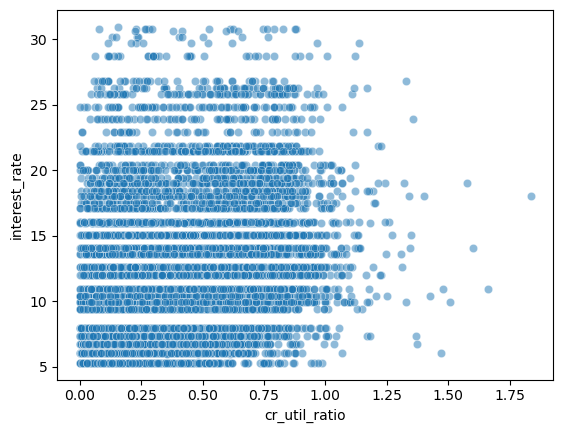

In [119]:
cols = ['loan_amount', 'effective_dti', 'cr_util_ratio']

for col in cols:
    sns.scatterplot(data=df, x=col, y='interest_rate', alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('interest_rate')
    plt.show()

In [120]:
# Scatter plot interpretation:

# Loan amount vs interest rate
# Very little visible relationship between loan amount and interest rate
# Interest rates are spread across a wide range for both small and large loans
# So loan amount alone does not seem to strongly explain the interest rate

# Effective DTI vs interest rate
# Slight positive relationship with interest rate
# Higher DTI tends to be associated with somewhat higher interest rates
# But the points are widely scattered, so the relationship is still weak

# Credit utilization vs interest rate
# Similar to effective DTI, there is a slight positive relationship with interest rate
# Higher credit utilization tends to have somewhat higher interest rates
# But there is a lot of variation, so credit utilization alone does not strongly determine the interest rate

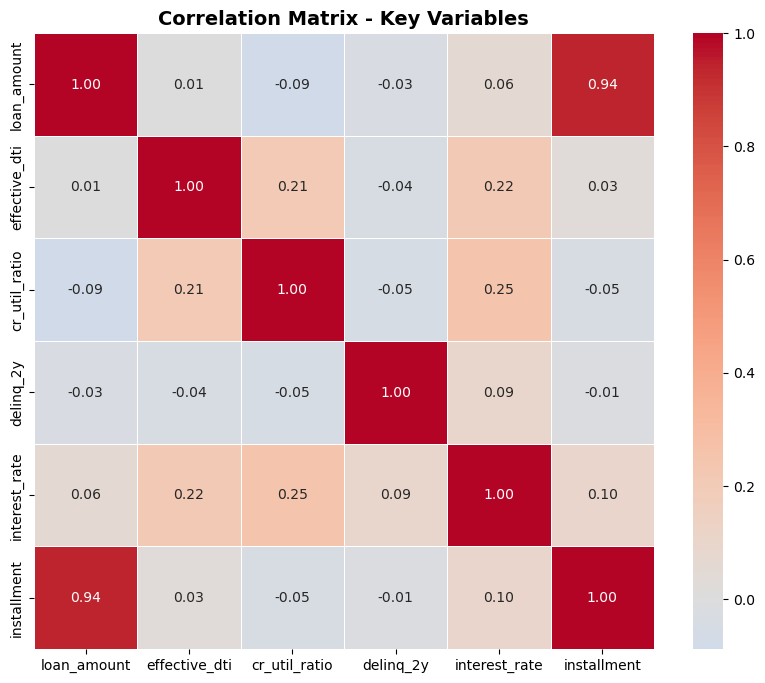

In [121]:
# Select key numerical columns for correlation
corr_columns = ['loan_amount', 'effective_dti', 'cr_util_ratio', 
                'delinq_2y', 'interest_rate', 'installment']

# Calculate correlation matrix
corr_matrix = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            linewidths=.5, fmt='.2f')
plt.title('Correlation Matrix - Key Variables', fontsize=14, fontweight='bold')
plt.show()

In [122]:
# Correlation matrix interpretation:

# Interest rate has a weak positive correlation with effective DTI (0.22)
# and credit utilization ratio (0.25)
# Higher values of these variables are somewhat associated with higher interest rates

# Interest rate has almost no linear correlation with loan amount (0.06)
# or delinquency history (0.09)

# Loan amount and installment have a very strong positive correlation (0.94)
# This makes sense because installment is largely based on loan amount,
# along with interest rate and loan term

# Overall, none of the numeric variables shown here has a strong linear correlation with interest rate
# This does not mean they are useless
# The relationship can still be non-linear or affected by other variables

In [123]:
# 1. Define the columns to drop
columns_to_drop = [
    'emp_title', 
    'state',    # High cardinality

    
    'balance', 
    'paid_total', 
    'paid_principal', 
    'paid_interest', 
    'paid_late_fees', 
    'loan_status',     # Post-origination data, cant predict interest from this
    
    
    'grade', 
    'sub_grade', # Output buckets of the interest rate
    

    'annual_income',           # Replaced by effective_income
    'annual_income_joint',     # Replaced by effective_income
    'debt_to_income',          # Replaced by effective_dti
    'debt_to_income_joint',    # Replaced by effective_dti
    'verified_income',         # Replaced by income_verification_status
    'verification_income_joint', # Replaced by income_verification_status
    
    # Metadata / IDs
    'issue_month',
    'initial_listing_status',
    'disbursement_method'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 3. Verify what is left
print(f"Remaining columns: {df.shape[1]}")
print(df.columns)

Remaining columns: 48
Index(['emp_length', 'homeownership', 'delinq_2y', 'months_since_last_delinq',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt',
       'loan_purpose', 'application_type', 'loan_amount', 'term',
       'interest_rate', 'installment', 'issue_year', 'credit_history_years',
  

In [124]:
df.head()

,emp_length,homeownership,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,issue_year,credit_history_years,effective_income,effective_dti,installment_to_income,cr_util_ratio,loan_to_income,has_recent_inquiry,ever_90d_late,has_ever_been_delinquent,income_verification_status,emp_length_missing
0,3.00,MORTGAGE,0,38.00,2001,6,28,10,70795,38767,0,0,38.00,0,1250,2,5,5.00,10,0.00,0,2,11100,14,8,6,1,92.90,0,0,moving,individual,28000,60,14.07,652.53,1,-2000,90000.00,18.01,0.09,0.55,0.31,1,1,1,Verified,0
1,10.00,RENT,0,0.00,1996,1,30,14,28800,4321,0,1,0.00,0,0,0,11,8.00,14,0.00,0,3,16500,24,14,4,0,100.00,0,1,debt_consolidation,individual,5000,36,12.61,167.54,1,-1995,40000.00,5.04,0.05,0.15,0.12,1,0,0,Not Verified,0
2,3.00,RENT,0,28.00,2006,4,31,10,24193,16000,0,0,28.00,0,432,1,13,7.00,10,0.00,0,3,4300,14,8,6,0,93.50,0,0,other,individual,2000,36,17.09,71.40,1,-2005,40000.00,21.15,0.02,0.66,0.05,1,1,1,Source Verified,0
3,1.00,RENT,0,0.00,2007,0,4,4,25400,4997,0,1,0.00,0,0,1,1,15.00,4,0.00,0,2,19400,3,3,2,0,100.00,1,0,debt_consolidation,individual,21600,36,6.72,664.19,1,-2006,30000.00,10.16,0.27,0.20,0.72,1,0,0,Not Verified,0
4,10.00,RENT,0,0.00,2008,7,22,16,69839,52722,0,0,0.00,0,0,1,6,4.00,16,0.00,0,10,32700,20,15,13,0,100.00,0,0,credit_card,joint,23000,36,14.07,786.87,1,-2007,57000.00,37.66,0.17,0.75,0.40,1,0,0,Verified,0


In [125]:
# No logical checks related to balance, loan amount, interest paid, 
# and late fees are required since we have already dropped all those columns. 

In [126]:
# Removing the incorrectly calculated credit-history features and keep earliest_credit_line as the original proxy for credit history.
df.drop(columns=['issue_year', 'credit_history_years'], errors='ignore', inplace=True)

In [127]:
# Log transforms the heavily right-skewed continuous financial variables
df['log_effective_income'] = np.log1p(df['effective_income'])
df['log_loan_amount'] = np.log1p(df['loan_amount'])
df['log_total_credit_limit'] = np.log1p(df['total_credit_limit'])

In [128]:
# Dropping the raw versions of the columns we log-transformed
df.drop(columns=['effective_income', 'loan_amount', 'total_credit_limit'], inplace=True, errors='ignore')

In [129]:
# one hot encoding the categorical columns
cat_cols = [
    'homeownership', 
    'loan_purpose', 
    'application_type', 
    'income_verification_status'
]

# drop_first=True prevents the Dummy Variable Trap 
# dtype=int to get 0/1 instead of True/False, better for statistics
df= pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# Check
print(f"Original columns: {df.shape[1]}")
print(f"Encoded columns: {df_encoded.shape[1]}")
print("\nFirst few encoded columns:")
print(df.head())

Original columns: 58
Encoded columns: 58

First few encoded columns:
   emp_length  delinq_2y  months_since_last_delinq  earliest_credit_line  \
0        3.00          0                     38.00                  2001   
1       10.00          0                      0.00                  1996   
2        3.00          0                     28.00                  2006   
3        1.00          0                      0.00                  2007   
4       10.00          0                      0.00                  2008   

   inquiries_last_12m  total_credit_lines  open_credit_lines  \
0                   6                  28                 10   
1                   1                  30                 14   
2                   4                  31                 10   
3                   0                   4                  4   
4                   7                  22                 16   

   total_credit_utilized  num_collections_last_12m  \
0                  38767           

In [131]:
df.head()

,emp_length,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,term,interest_rate,installment,effective_dti,installment_to_income,cr_util_ratio,loan_to_income,has_recent_inquiry,ever_90d_late,has_ever_been_delinquent,emp_length_missing,log_effective_income,log_loan_amount,log_total_credit_limit,homeownership_OWN,homeownership_RENT,loan_purpose_credit_card,loan_purpose_debt_consolidation,loan_purpose_home_improvement,loan_purpose_house,loan_purpose_major_purchase,loan_purpose_medical,loan_purpose_moving,loan_purpose_other,loan_purpose_renewable_energy,loan_purpose_small_business,loan_purpose_vacation,application_type_joint,income_verification_status_Source Verified,income_verification_status_Verified
0,3.00,0,38.00,2001,6,28,10,38767,0,0,38.00,0,1250,2,5,5.00,10,0.00,0,2,11100,14,8,6,1,92.90,0,0,60,14.07,652.53,18.01,0.09,0.55,0.31,1,1,1,0,11.41,10.24,11.17,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,10.00,0,0.00,1996,1,30,14,4321,0,1,0.00,0,0,0,11,8.00,14,0.00,0,3,16500,24,14,4,0,100.00,0,1,36,12.61,167.54,5.04,0.05,0.15,0.12,1,0,0,0,10.60,8.52,10.27,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3.00,0,28.00,2006,4,31,10,16000,0,0,28.00,0,432,1,13,7.00,10,0.00,0,3,4300,14,8,6,0,93.50,0,0,36,17.09,71.40,21.15,0.02,0.66,0.05,1,1,1,0,10.60,7.60,10.09,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3,1.00,0,0.00,2007,0,4,4,4997,0,1,0.00,0,0,1,1,15.00,4,0.00,0,2,19400,3,3,2,0,100.00,1,0,36,6.72,664.19,10.16,0.27,0.20,0.72,1,0,0,0,10.31,9.98,10.14,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,10.00,0,0.00,2008,7,22,16,52722,0,0,0.00,0,0,1,6,4.00,16,0.00,0,10,32700,20,15,13,0,100.00,0,0,36,14.07,786.87,37.66,0.17,0.75,0.40,1,0,0,0,10.95,10.04,11.15,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1


In [134]:
# Defining Features (X) and Target (y)
# Target is interest_rate. Features are you other and engineered columns in df.
X = df.drop(columns=['interest_rate']) # Drop target and any ID columns
y = df['interest_rate']


#Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [135]:
# Initializing the basic Linear Regression model, and building basic model, calculating metrics and doing model evaluation

basic_model = LinearRegression()

basic_model.fit(X_train, y_train)

y_train_pred = basic_model.predict(X_train)
y_test_pred = basic_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 5. Print the results
print("--- MODEL EVALUATION METRICS ---")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE:  {test_rmse:.4f}")
print(f"Training R-squared: {train_r2:.4f}")
print(f"Testing R-squared:  {test_r2:.4f}")
print(f"Testing MAE:        {test_mae:.4f}")

--- MODEL EVALUATION METRICS ---
Training RMSE: 2.9630
Testing RMSE:  3.0115
Training R-squared: 0.6436
Testing R-squared:  0.6579
Testing MAE:        2.3406


In [137]:
scores = [] # an empty list to store the scores

for i in range(1000):
    # Splitting the data with a different random state each time
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores.append(score)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"--- MONTE CARLO VALIDATION RESULTS ---")
print(f"Mean R-squared:    {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")


--- MONTE CARLO VALIDATION RESULTS ---
Mean R-squared:    0.6389
Standard Deviation: 0.0154


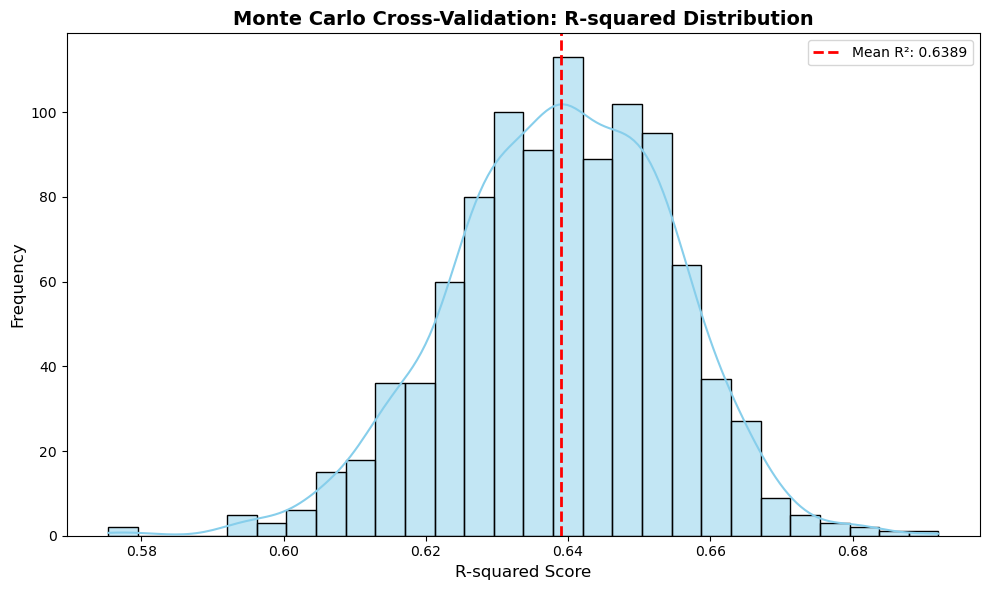

In [138]:
# 4. Visualize the distribution of the scores
plt.figure(figsize=(10, 6))

sns.histplot(scores, kde=True, color='skyblue', edgecolor='black')

plt.axvline(mean_score, 
            color='red', 
            linestyle='dashed', 
            linewidth=2, 
            label=f'Mean R²: {mean_score:.4f}')

plt.title('Monte Carlo Cross-Validation: R-squared Distribution', fontsize=14, fontweight='bold')
plt.xlabel('R-squared Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## MONTE CARLO CROSS-VALIDATION INTERPRETATION:
--------------------------------------------
1. Model Stability (Standard Deviation = 0.0154):
   The standard deviation is extremely low (1.54%). This proves that our model is highly 
   stable and robust. It is not overfitting to a specific subset of the training data. 
   Regardless of how the data is randomly split, the model consistently performs within 
   a very tight range (between ~0.62 and ~0.66 R-squared).

2. Consistent Predictive Power (Mean R-squared = 0.6389):
   Across 1000 different random train/test splits, the model explains an average of 63.89% 
   of the variance in the interest rate. This confirms that our previous single split 
   (R² = 0.65) was not a statistical fluke, but a true representation of the model's capability.

3. Normal Distribution:
   The histogram shows a perfect bell curve (normal distribution) centered around the mean. 
   This indicates that the errors are randomly distributed and the model's performance is 
   predictable and reliable in a production environment.

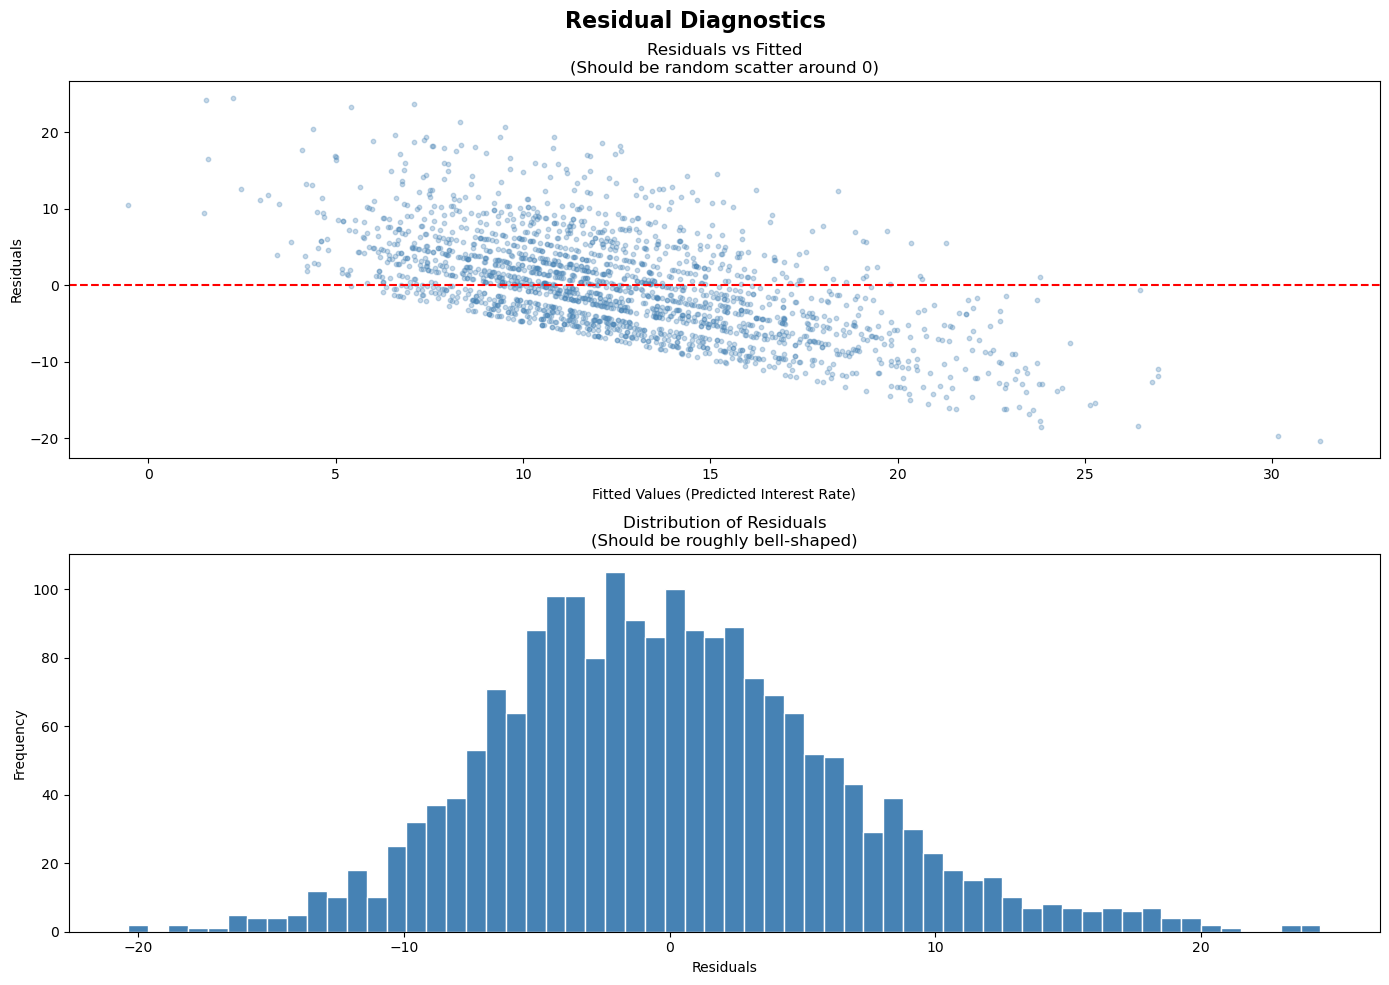

In [142]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Residual Diagnostics', fontsize=16, fontweight='bold')

# --- Plot 1: Residuals vs Fitted ---
axes[0].scatter(y_test_pred, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values (Predicted Interest Rate)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(Should be random scatter around 0)')

# --- Plot 2: Distribution of Residuals ---
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals\n(Should be roughly bell-shaped)')

plt.tight_layout()
plt.show()

In [196]:
# INTERPRETATION of RESIDUALS VS FITTED
# The plot shows a downward slope from left to right
# At low predicted rates, residuals are mostly positive
#   -> model is underpredicting (actual rate is higher than predicted)
# At high predicted rates, residuals are mostly negative
#   -> model is overpredicting (actual rate is lower than predicted)
# This pattern means the model is pulling predictions toward the middle
# and struggling with the extremes — a sign of missing non-linearity
#
# INTERPRETATION of DISTRIBUTION OF RESIDUALS (2nd grpah)
# Roughly bell-shaped and centred near 0 — acceptable
# Slight left skew (tail extends further to -20 than to +20)
# Means the model occasionally makes larger underpredictions than overpredictions

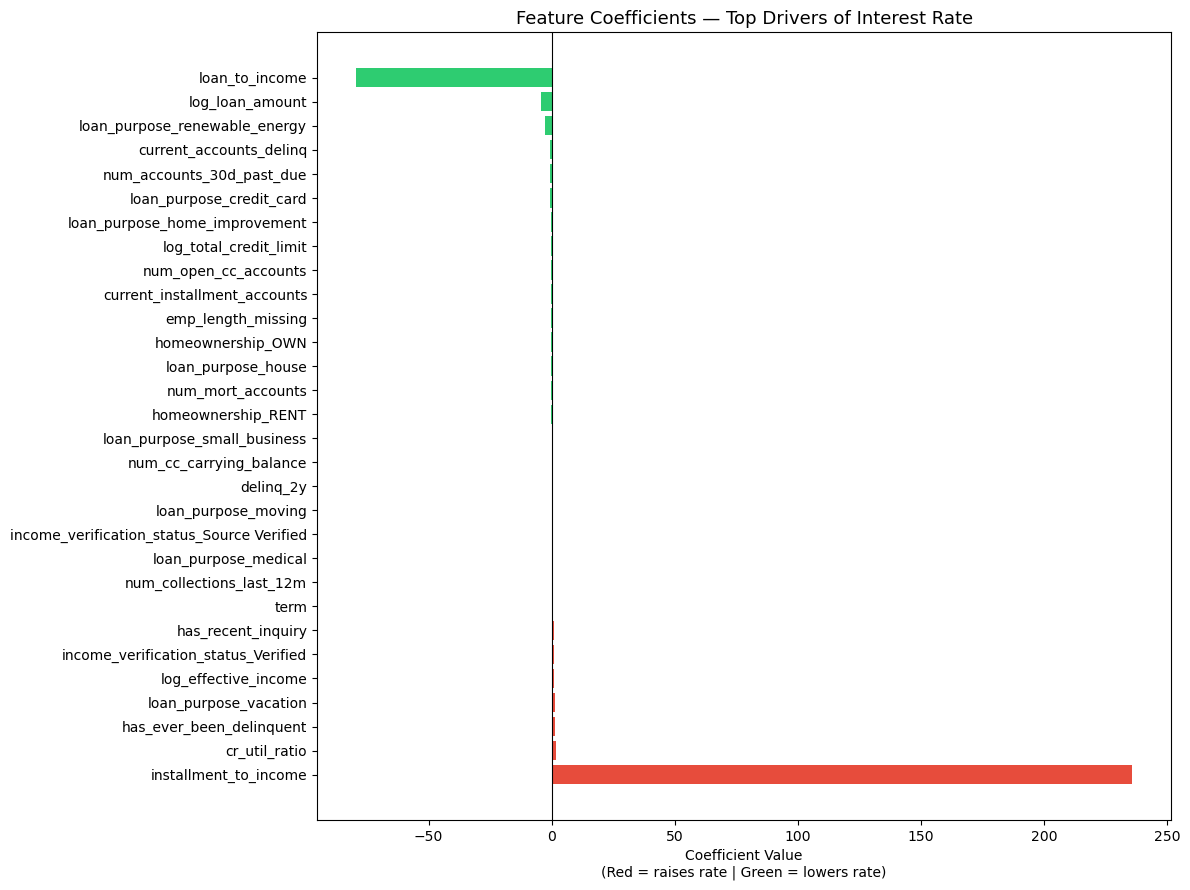

                                       Feature  Coefficient
0                        installment_to_income       235.93
1                                cr_util_ratio         1.86
2                     has_ever_been_delinquent         1.35
3                        loan_purpose_vacation         1.19
4                         log_effective_income         1.09
5          income_verification_status_Verified         0.96
6                           has_recent_inquiry         0.76
7                                         term         0.49
8                     num_collections_last_12m         0.45
9                         loan_purpose_medical         0.41
10  income_verification_status_Source Verified         0.36
11                         loan_purpose_moving         0.26
12                                   delinq_2y         0.18
13                     num_cc_carrying_balance         0.15
14                 loan_purpose_small_business         0.15
15                         accounts_open

In [153]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': basic_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

# Top 15 positive (increase interest rate) + Top 15 negative (decrease interest rate)
top_bottom = pd.concat([coef_df.head(15), coef_df.tail(15)])

plt.figure(figsize=(12, 9))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_bottom['Coefficient']]
plt.barh(top_bottom['Feature'], top_bottom['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Top Drivers of Interest Rate', fontsize=13)
plt.xlabel('Coefficient Value\n(Red = raises rate | Green = lowers rate)')
plt.tight_layout()
plt.show()

print(coef_df.to_string())

## Leakage Investigation, now removing `installment_to_income`

The feature coefficient chart from the previous model revealed that `installment_to_income` 
had a coefficient of ~235 which is far larger than any other feature, with everything else 
barely visible on the same scale.

On reflection, this makes sense for the wrong reason. `installment_to_income` was engineered 
as monthly installment divided by monthly income. But `installment` itself is calculated 
from loan amount, loan term, and interest rate which is our target variable. 
So this feature was partially encoding the answer we were trying to predict. 
This is known as feature leakage.

The model wasn't learning the relationship between borrower risk and interest rate. 
It was partly reading the interest rate off the installment figure and feeding it back 
to itself. That is not generalizable knowledge.

To confirm this, the feature is dropped below and the entire model pipeline is rerun. 
If the leakage hypothesis is correct, R² should drop significantly — because the model 
will have lost access to that shortcut.

In [165]:
X = X.drop(columns='installment_to_income')

KeyError: "['installment_to_income'] not found in axis"

In [168]:
#Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [169]:
# Initializing the basic Linear Regression model, and building basic model, calculating metrics and doing model evaluation

basic_model = LinearRegression()

basic_model.fit(X_train, y_train)

y_train_pred = basic_model.predict(X_train)
y_test_pred = basic_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 5. Print the results
print("--- MODEL EVALUATION METRICS ---")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE:  {test_rmse:.4f}")
print(f"Training R-squared: {train_r2:.4f}")
print(f"Testing R-squared:  {test_r2:.4f}")
print(f"Testing MAE:        {test_mae:.4f}")

--- MODEL EVALUATION METRICS ---
Training RMSE: 3.6205
Testing RMSE:  3.6903
Training R-squared: 0.4678
Testing R-squared:  0.4863
Testing MAE:        2.8594


In [197]:
# MODEL EVALUATION METRICS
# R²   = how much of the variance in interest rate the model explains
#        0 = no better than guessing the mean; 1 = perfect predictions
# RMSE = average error in % points, with large errors penalised more
# MAE  = plain average error in % points (simpler, treats all errors equally)
#
# RESULTS:
# Training R² (0.47) ≈ Testing R² (0.49) -> no overfitting
# The tiny gap (and slight test advantage) is normal for large datasets
# RMSE 3.69 -> predictions are roughly ±3.7 percentage points on average
# MAE  2.86 -> typical plain error is about ±2.9 percentage points
#
# The R² drop from the original model's 0.66 to 0.49 here confirms
# the leakage hypothesis — installment_to_income was carrying ~17 points
# of R² through an artificial shortcut, not genuine signal

In [170]:
# DOING MONTE CARLO VALIDATION

scores = [] # an empty list to store the scores

for i in range(1000):
    # Splitting the data with a different random state each time
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores.append(score)

mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"--- MONTE CARLO VALIDATION RESULTS ---")
print(f"Mean R-squared:    {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")


--- MONTE CARLO VALIDATION RESULTS ---
Mean R-squared:    0.4612
Standard Deviation: 0.0174


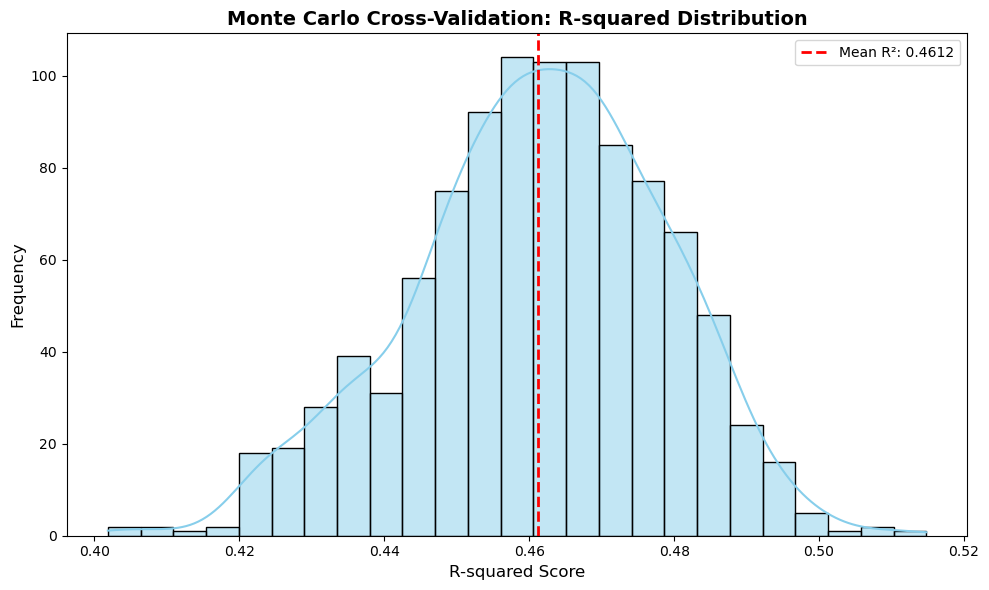

In [171]:
# 4. Visualize the distribution of the scores
plt.figure(figsize=(10, 6))

sns.histplot(scores, kde=True, color='skyblue', edgecolor='black')

plt.axvline(mean_score, 
            color='red', 
            linestyle='dashed', 
            linewidth=2, 
            label=f'Mean R²: {mean_score:.4f}')

plt.title('Monte Carlo Cross-Validation: R-squared Distribution', fontsize=14, fontweight='bold')
plt.xlabel('R-squared Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [199]:
# MONTE CARLO CROSS-VALIDATION (1000 random splits)
# Runs train-test split 1000 times with different random seeds
# and collects R² from each run — gives a distribution of performance
# rather than a single number from one lucky or unlucky split
#
# RESULTS:
# Mean R²: 0.4612 | Std Dev: 0.0174
# The histogram shows a tight bell curve centred at 0.46
# Low std dev means the model performs consistently across all splits
# The model is stable — not sensitive to which loans land in test set


In [198]:

# RESIDUAL ANALYSIS
# Residual = actual interest rate − predicted interest rate
# Positive residual -> model underpredicted (actual was higher)
# Negative residual -> model overpredicted (actual was lower)
# A good model has residuals that look like random noise around zero


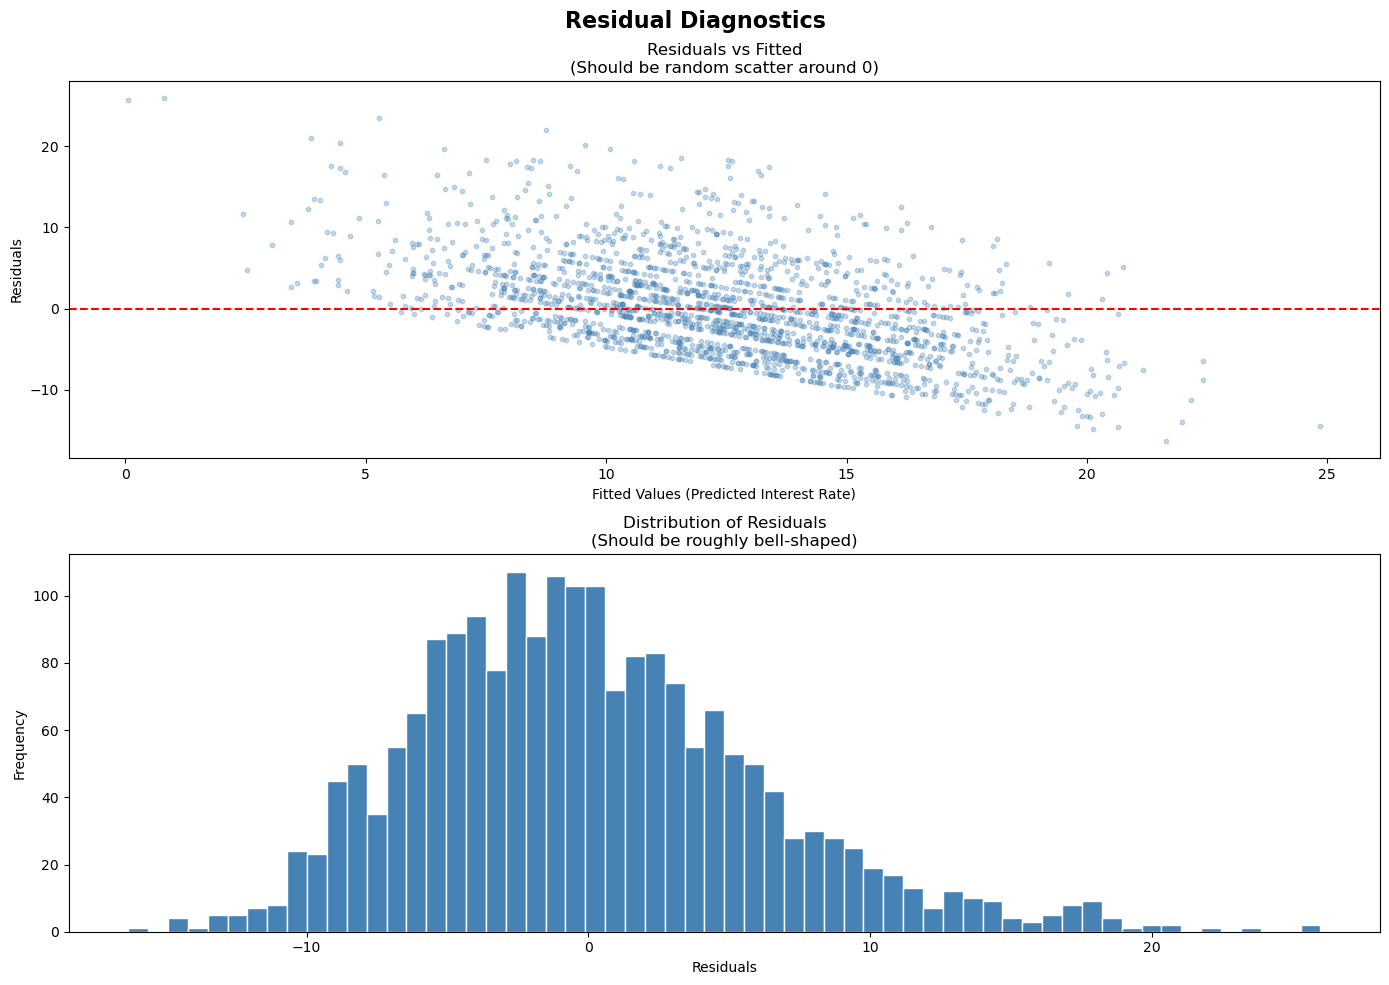

In [173]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Residual Diagnostics', fontsize=16, fontweight='bold')

# --- Plot 1: Residuals vs Fitted ---
axes[0].scatter(y_test_pred, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values (Predicted Interest Rate)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(Should be random scatter around 0)')

# --- Plot 2: Distribution of Residuals ---
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals\n(Should be roughly bell-shaped)')

plt.tight_layout()
plt.show()

In [175]:
# RESIDUALS VS FITTED
# The downward slope is still present -> same pattern as the original model
# Low predictions -> mostly positive residuals (model underpredicts low rates)
# High predictions -> mostly negative residuals (model overpredicts high rates)
#
# Key insight: this pattern survived the removal of the leaky feature
# This means the non-linearity is real and fundamental to the data
# It was not caused by installment_to_income -> it was always there
# Linear regression cannot capture this -> it is hitting its ceiling
# A tree-based model (Random Forest, XGBoost) would handle this better
#
# INTERPRETATION —> DISTRIBUTION OF RESIDUALS
# Roughly bell-shaped but with a right tail extending toward +20
# Slight skew means the model makes more large underpredictions than overpredictions
# Acceptable for a real-world financial dataset


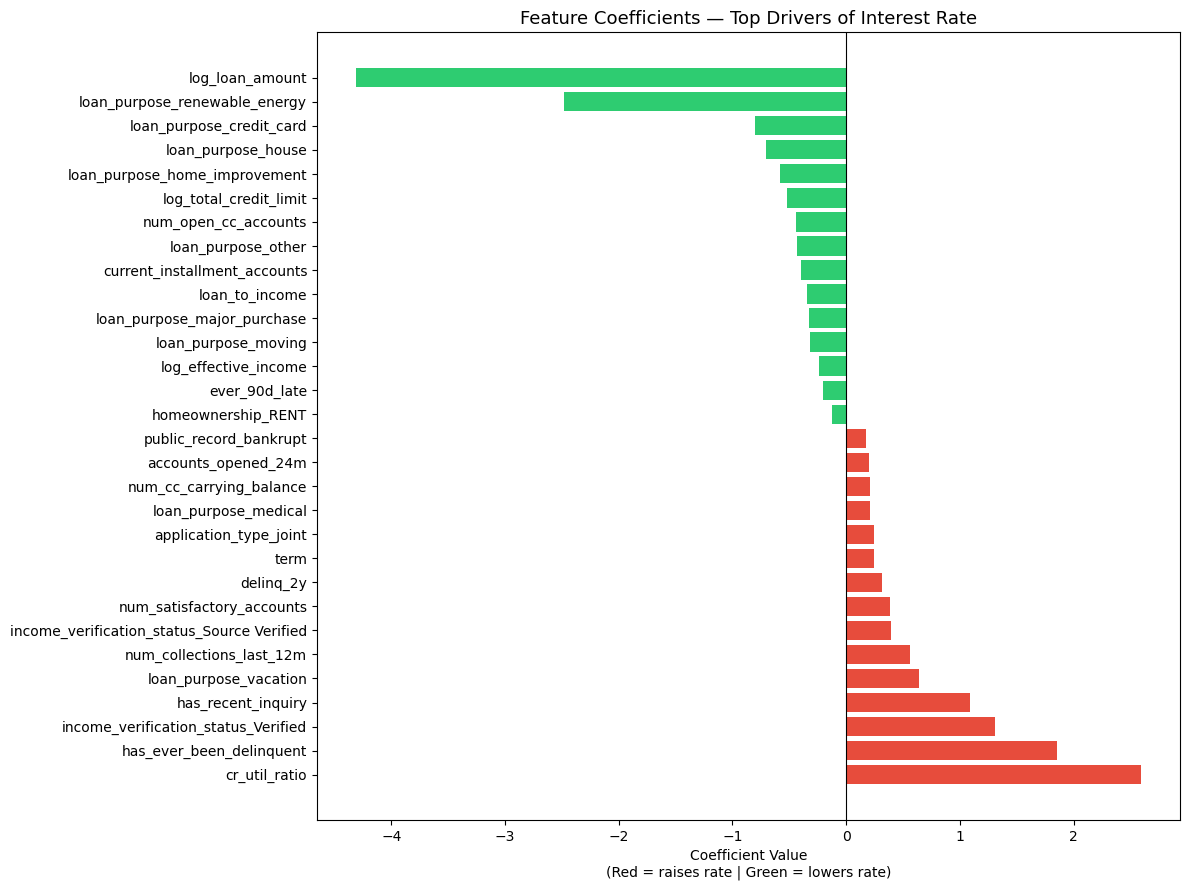

                                       Feature  Coefficient
0                                cr_util_ratio         2.59
1                     has_ever_been_delinquent         1.86
2          income_verification_status_Verified         1.31
3                           has_recent_inquiry         1.09
4                        loan_purpose_vacation         0.64
5                     num_collections_last_12m         0.56
6   income_verification_status_Source Verified         0.39
7                    num_satisfactory_accounts         0.39
8                                    delinq_2y         0.32
9                                         term         0.25
10                      application_type_joint         0.24
11                        loan_purpose_medical         0.21
12                     num_cc_carrying_balance         0.21
13                         accounts_opened_24m         0.20
14                      public_record_bankrupt         0.17
15                   num_active_debit_ac

In [176]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': basic_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

# Top 15 positive (increase interest rate) + Top 15 negative (decrease interest rate)
top_bottom = pd.concat([coef_df.head(15), coef_df.tail(15)])

plt.figure(figsize=(12, 9))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_bottom['Coefficient']]
plt.barh(top_bottom['Feature'], top_bottom['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Top Drivers of Interest Rate', fontsize=13)
plt.xlabel('Coefficient Value\n(Red = raises rate | Green = lowers rate)')
plt.tight_layout()
plt.show()

print(coef_df.to_string())

In [178]:
# ============================================
# FEATURE COEFFICIENTS
# With installment_to_income removed, the chart is finally readable
# Coefficients now range from -5 to +2.5 — balanced and interpretable
# Every feature contributes meaningfully rather than one dominating
# ==============================================

In [179]:
# 
# INTERPRETATION — FEATURE COEFFICIENTS
#
# TOP POSITIVE (raise predicted interest rate):
# cr_util_ratio (+2.5)          -> high credit utilisation = financial stress = higher rate
# has_ever_been_delinquent (+1.9) -> past missed payments = higher risk = higher rate
# income_verification_Verified (+1.3) -> verified borrowers may be higher-risk profiles
# has_recent_inquiry (+1.2)     -> recent credit applications signal active financial need
#
# TOP NEGATIVE (lower predicted interest rate):
# log_loan_amount (-5)          -> larger loans go to more creditworthy borrowers on this platform
# loan_purpose_renewable_energy (-3) -> lower-risk or subsidised loan purpose
# loan_purpose_credit_card, house, home_improvement (~-1) -> lower rate vs baseline category
# log_total_credit_limit (-0.7) -> high credit limit = previously trusted by lenders = lower rate
# log_effective_income (-0.3)   -> higher income = lower rate (expected)
#
# These directions all make intuitive sense that the model is learning real patterns
# ========

In [180]:
# PERFORMING CROSS VALIDATION

In [181]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(basic_model, X, y, cv=5, scoring='r2')
print(f"CV R² Scores: {cv_scores.round(4)}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

CV R² Scores: [0.4781 0.4262 0.4396 0.4874 0.4789]
Mean R²: 0.4620
Std Dev: 0.0244


In [189]:
# REGULARISATION — RIDGE AND LASSO
# Both add a penalty to the model to prevent overfitting
# Ridge: shrinks all coefficients but keeps all features
# Lasso: can push coefficients to exactly zero — automatic feature selection
# Alpha controls penalty strength: 0 = no penalty (same as basic LR)
# RidgeCV / LassoCV automatically test many alpha values and pick the best

In [182]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# Scale features (fit on train, transform both — never fit on test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

alphas = np.logspace(-3, 3, 100)  # Tests 100 alpha values from 0.001 to 1000


# ---- RIDGE ----
ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_cv.fit(X_train_scaled, y_train)
best_ridge_alpha = ridge_cv.alpha_
print(f"Best Ridge Alpha: {best_ridge_alpha:.4f}")

ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

ridge_r2   = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae  = mean_absolute_error(y_test, ridge_pred)


# ---- LASSO ----
lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
best_lasso_alpha = lasso_cv.alpha_
print(f"Best Lasso Alpha: {best_lasso_alpha:.4f}")

lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

lasso_r2   = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae  = mean_absolute_error(y_test, lasso_pred)


# ---- Lasso Feature Selection ----
lasso_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_
})

zeroed = (lasso_coef_df['Coefficient'] == 0).sum()
print(f"\nLasso eliminated {zeroed} features out of {len(lasso_coef_df)}")
print("\nFeatures that survived (non-zero coefficients):")
print(
    lasso_coef_df[lasso_coef_df['Coefficient'] != 0]
    .sort_values('Coefficient', ascending=False)
    .to_string(index=False)
)

Best Ridge Alpha: 13.2194
Best Lasso Alpha: 0.0248

Lasso eliminated 17 features out of 56

Features that survived (non-zero coefficients):
                                   Feature  Coefficient
                               installment         3.00
                                      term         2.65
                             effective_dti         0.96
                             cr_util_ratio         0.66
                  has_ever_been_delinquent         0.63
                   num_cc_carrying_balance         0.55
       income_verification_status_Verified         0.54
                       accounts_opened_24m         0.51
                 num_active_debit_accounts         0.33
                        has_recent_inquiry         0.31
                                 delinq_2y         0.24
                        inquiries_last_12m         0.24
                      earliest_credit_line         0.22
income_verification_status_Source Verified         0.18
           loan_purp

In [190]:
# INTERPRETATION of RIDGE AND LASSO RESULTS
# Basic LR outperformed both (R² 0.49 vs 0.47)
# The training and test R² were already close to each other,
# meaning the model was not significantly overfitting to begin with
# Regularisation had no real problem to fix, so the penalty
# ended up slightly hurting performance by shrinking useful coefficients
#
# Best Ridge Alpha: 13.22 -> strong penalty needed to control the
#           many small coefficients across 56 features
# Best Lasso Alpha: 0.0248 -> mild penalty overall, yet still enough
#     to zero out 17 features that contributed nothing
#
# Final verdict: for this dataset, basic LR is the better model
# Ridge and Lasso would matter more if overfitting were present

In [191]:
comparison = pd.DataFrame({
    'Model':  ['Basic LR', 'Ridge', 'Lasso'],
    'R²':     [test_r2,    ridge_r2,    lasso_r2],
    'RMSE':   [test_rmse,  ridge_rmse,  lasso_rmse],
    'MAE':    [test_mae,   ridge_mae,   lasso_mae],
})

print("=== FINAL MODEL COMPARISON ===")
print(comparison.to_string(index=False))


=== FINAL MODEL COMPARISON ===
   Model   R²  RMSE  MAE
Basic LR 0.49  3.69 2.86
   Ridge 0.47  3.70 2.83
   Lasso 0.47  3.72 2.85


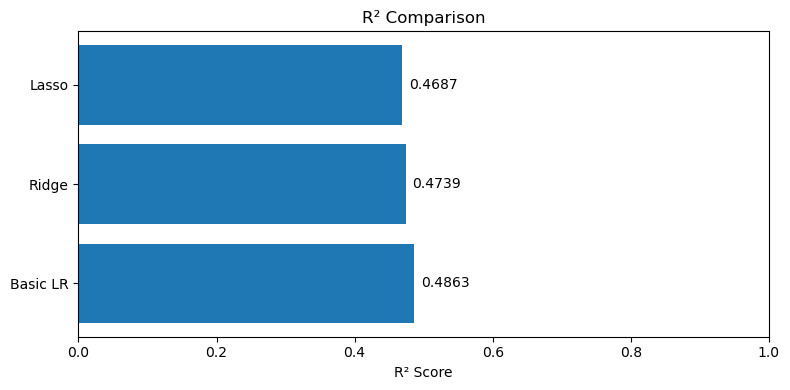

In [192]:
# R² comparison
plt.figure(figsize=(8, 4))

plt.barh(comparison['Model'], comparison['R²'])

plt.xlabel('R² Score')
plt.title('R² Comparison')
plt.xlim(0, 1)

for i, val in enumerate(comparison['R²']):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

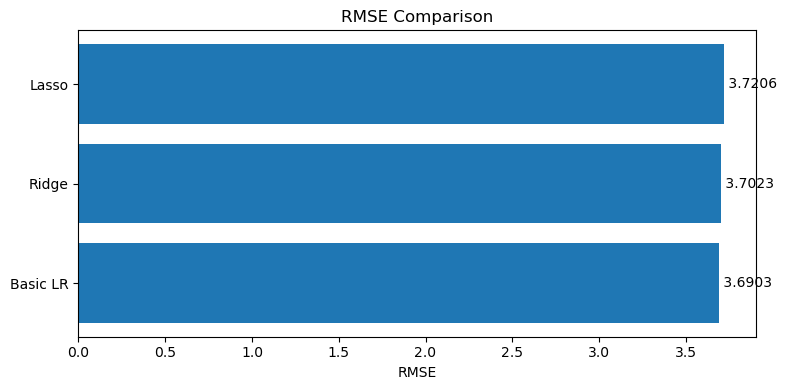

In [193]:
# RMSE Comparison
plt.figure(figsize=(8, 4))

plt.barh(comparison['Model'], comparison['RMSE'])

plt.xlabel('RMSE')
plt.title('RMSE Comparison')

for i, val in enumerate(comparison['RMSE']):
    plt.text(val, i, f' {val:.4f}', va='center')

plt.tight_layout()
plt.show()

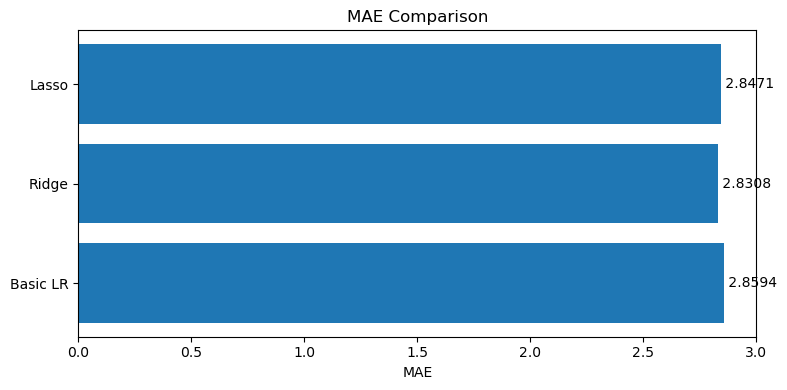

In [194]:
# MAE Comparison
plt.figure(figsize=(8, 4))

plt.barh(comparison['Model'], comparison['MAE'])

plt.xlabel('MAE')
plt.title('MAE Comparison')

for i, val in enumerate(comparison['MAE']):
    plt.text(val, i, f' {val:.4f}', va='center')

plt.tight_layout()
plt.show()

## Conclusion
-----
- This project built a linear regression model to predict interest rates on Lending Club loans.
  - I covered the full process from feature engineering and preprocessing to model evaluation, leakage investigation and regularisation.
  - The initial model got an R² of 0.66 on the test set.
-------
- The coefficient chart showed an immediate problem.
  - `installment_to_income` had a coefficient of around 235, which was much higher than every other feature.
  - After looking into it, this actually made sense for the wrong reason.
  - The installment column is calculated using loan amount, term and interest rate.
  - Since interest rate is the target, the model was partly reading the answer from the feature itself.
  - so this was clearly feature leakage.
-------
- After removing the leaky feature, the model was rebuilt.
  - R² dropped from 0.66 to 0.49.
  - This 17 percentage point drop showed that the original performance was artificially inflated.
  - The corrected model got an R² of 0.49, RMSE of 3.69 and MAE of 2.86.
  - These numbers are a more realistic picture of what linear regression can do with the legitmate features.
-------
- I also checked whether the model was stable across different splits.
  - Monte Carlo validation with 1000 random splits gave a mean R² of 0.46 with a standard deviation of 0.017.
  - 5-fold cross-validation gave a mean R² of 0.46 with a standard deviation of 0.024.
  - so both methods were giving almost the same result.
  - This suggests that the result is not just because of one particular train-test split.
-------
- The residual plots also showed something important.
  - There was a downward pattern in the residuals in both models.
  - The model tends to underpredict lower interest rates and overpredict higher interest rates.
  - This pattern was still there even after removing the leaky feature.
  - so this seems to be an actual limitation of the linear model.
  - The relationship between borrower characteristics and interest rate is probably not fully linear.
-------
- The clean model's coefficient chart was probably the most useful output for understanding the model.
  - Credit utilisation ratio, delinquency history and recent credit inquiries were some of the strongest positive drivers of interest rate.
  - Log-transformed loan amount was the strongest negative driver.
  - On this dataset, larger loans seem to be going more towards borrowers with stronger credit profiles.
  - These directions also make sense from a credit risk point of view.
  - It also gives some confidence that the model is learning real patterns and not just random noise.
-------
- I also compared regularisation models.
  - Basic Linear Regression had an R² of 0.49.
  - Ridge and Lasso were both around 0.47.
  - so regularisation did not really improve the model.
  - Lasso did zero out 17 out of 56 features, which was useful for seeing which features were not contributing much.
-------
- The next step would probably be trying a tree based model like Random Forest or XGBoost.
  - Linear regression is not able to properly capture non-linear relationships and interactions between features.
  - A tree based model can handle these much better.
  - This could potentially improve the performance beyond the 0.49 R² reached by the current model.
  - but that would be the next part of the project, not something tested here.
--------